# Chi-Square Test of Independence

## Objective

To determine whether there is a statistically significant association
between two categorical variables using the Chi-Square Test of Independence.

### Dataset
Titanic Dataset

### Variables
- Sex
- Survived

### Tools
- Python
- Pandas
- NumPy
- SciPy
- Matplotlib
- Seaborn
- Google Colab

### Significance Level
α = 0.05

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [4]:
df = df[['sex', 'survived']]

df.head()

,sex,survived
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


In [5]:
print(df.isnull().sum())

sex         0
survived    0
dtype: int64


In [6]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (891, 2)


In [7]:
df['survived_label'] = df['survived'].map({
    0: 'Did Not Survive',
    1: 'Survived'
})

df.head()

,sex,survived,survived_label
0,male,0,Did Not Survive
1,female,1,Survived
2,female,1,Survived
3,female,1,Survived
4,male,0,Did Not Survive


In [8]:
contingency_table = pd.crosstab(
    df['sex'],
    df['survived_label']
)

print("Contingency Table:")
print(contingency_table)

Contingency Table:
survived_label  Did Not Survive  Survived
sex                                      
female                       81       233
male                        468       109


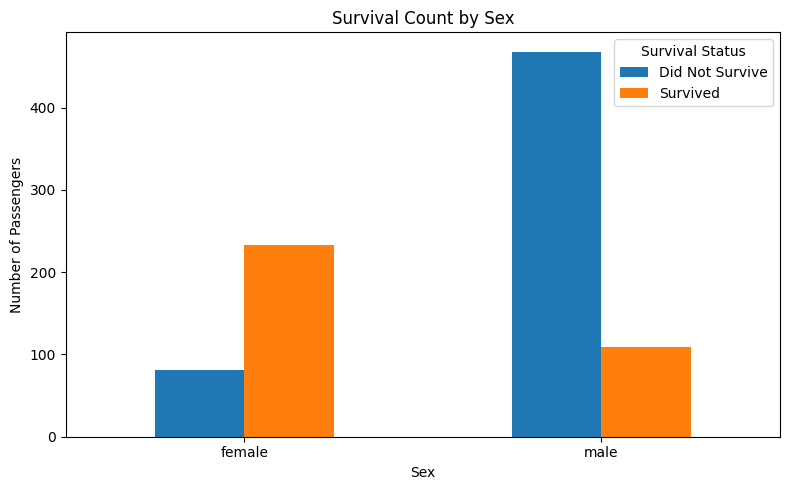

In [9]:
contingency_table.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.legend(title='Survival Status')
plt.tight_layout()
plt.show()

In [10]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("Expected Frequencies:")
print(expected_table)

Expected Frequencies:
survived_label  Did Not Survive    Survived
sex                                        
female               193.474747  120.525253
male                 355.525253  221.474747


In [11]:
print("Minimum expected frequency:",
      expected.min())

Minimum expected frequency: 120.52525252525253


In [12]:
if (expected >= 5).all():
    print("All expected frequencies are >= 5.")
else:
    print("Some expected frequencies are < 5.")

All expected frequencies are >= 5.


In [13]:
print("Chi-Square Test Results")
print("-----------------------")

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", degrees_of_freedom)

Chi-Square Test Results
-----------------------
Chi-Square Statistic: 260.71702016732104
P-value: 1.1973570627755645e-58
Degrees of Freedom: 1


In [14]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association")
    print("between sex and survival status.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant association")
    print("between sex and survival status.")

Decision: Reject the null hypothesis.
Conclusion: There is a statistically significant association
between sex and survival status.


In [15]:
percentage_table = pd.crosstab(
    df['sex'],
    df['survived_label'],
    normalize='index'
) * 100

print("Percentage of survival outcomes within each sex:")
print(percentage_table.round(2))

Percentage of survival outcomes within each sex:
survived_label  Did Not Survive  Survived
sex                                      
female                    25.80     74.20
male                      81.11     18.89


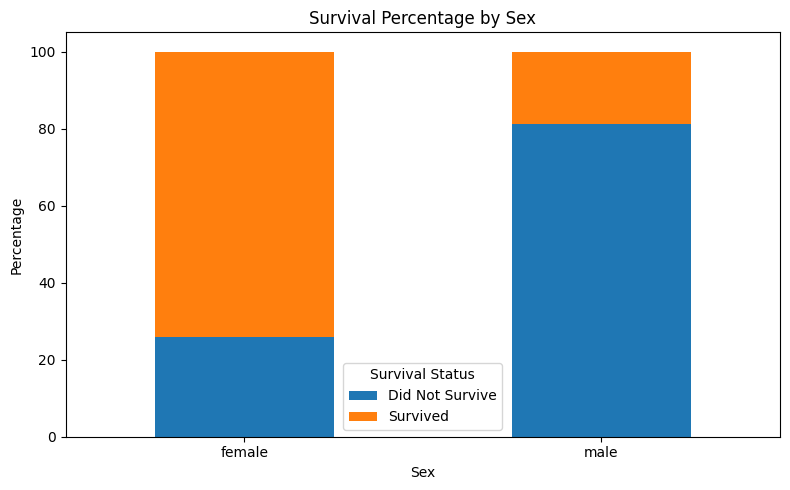

In [16]:
percentage_table.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Survival Percentage by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Survival Status')
plt.tight_layout()
plt.show()

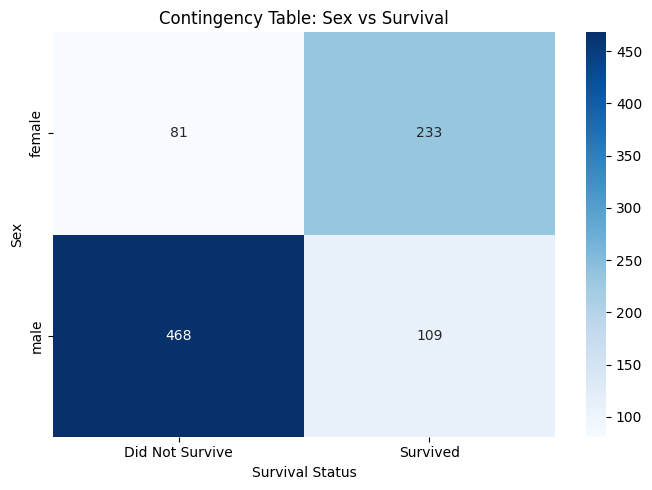

In [17]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Contingency Table: Sex vs Survival')
plt.xlabel('Survival Status')
plt.ylabel('Sex')

plt.tight_layout()
plt.show()